# VCA 3º GIA  — Práctica 2
## Fiz Garrido Escudero | Miguel Baños Baladrón
## Segmentación de fluido patológico en imágenes OCT

## Sección 0 — Setup

In [1]:
from google.colab import drive
import os

drive.mount('/content/gdrive')

route = '/content/gdrive/MyDrive/VCA/Practica2'
os.makedirs(f'{route}/models', exist_ok=True)

print(f'Ruta del proyecto: {route}')
%cd $route

import torch
torch.backends.cudnn.benchmark = True

Mounted at /content/gdrive
Ruta del proyecto: /content/gdrive/MyDrive/VCA/Practica2
/content/gdrive/MyDrive/VCA/Practica2


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import glob
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms.functional import InterpolationMode
import torchvision.transforms as transforms

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

IMG_DIR   = f'{route}/OCT-dataset/images'
MASK_DIR  = f'{route}/OCT-dataset/masks'
RSIZE     = (416, 624)
BATCH_SIZE = 4

Dispositivo: cuda


### Funciones de visualización

In [4]:
def show(image, mask, title=None):
    """Muestra una imagen OCT y su máscara binaria lado a lado."""
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image, cmap='gray')
    ax[0].axis('off')
    if title is not None:
        fig.suptitle(title)
    ax[1].imshow(mask, cmap='gray')
    ax[1].axis('off')
    plt.show()


def get_segmentation_masks(outputs, threshold=0.5):
    """Convierte los logits crudos de la red en una máscara binaria aplicando sigmoid y umbral."""
    probs = torch.sigmoid(outputs)
    masks = (probs > threshold) * 1.0
    return masks


def show_result(orig, gt, prediction, title=None):
    """
    Muestra 4 paneles: imagen original, máscara ground truth, predicción de la red
    y overlay sobre la imagen original donde verde indica detección correcta (TP)
    y rojo indica error (FP o FN).
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    ax = axes.ravel()

    orig_np = orig.numpy() if hasattr(orig, 'numpy') else np.array(orig)
    gt_np   = (gt.numpy() if hasattr(gt, 'numpy') else np.array(gt)) > 0.5
    pred_np = (prediction.numpy() if hasattr(prediction, 'numpy') else np.array(prediction)) > 0.5

    ax[0].imshow(orig_np, cmap='gray')
    ax[0].set_title('Orig')
    ax[0].axis('off')

    ax[1].imshow(gt_np, cmap='gray')
    ax[1].set_title('GT')
    ax[1].axis('off')

    ax[2].imshow(pred_np, cmap='gray')
    ax[2].set_title('Prediction')
    ax[2].axis('off')

    overlay = np.stack([orig_np, orig_np, orig_np], axis=-1)
    overlay[gt_np & pred_np]    = [0.0, 1.0, 0.0]
    overlay[(~gt_np) & pred_np] = [1.0, 0.0, 0.0]
    overlay[gt_np & (~pred_np)] = [1.0, 0.0, 0.0]

    ax[3].imshow(overlay)
    ax[3].set_title('Overlay (verde=TP, rojo=FP/FN)')
    ax[3].axis('off')

    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Sección 1 — Análisis exploratorio del dataset

Antes de diseñar el pipeline de entrenamiento, analizamos las características estadísticas del dataset para justificar las decisiones de diseño:
- **Brillo y contraste**: derivan los parámetros de `ColorJitter` para el augmentation.
- **Rango dinámico**: justifica el uso de CLAHE.
- **% de fluido por máscara**: cuantifica el desbalanceo real de clases, justifica Dice Loss.

In [5]:
def compute_stats(img_path, mask_path):
    img  = plt.imread(img_path)
    mask = plt.imread(mask_path)
    if len(img.shape) > 2:
        img = img[:, :, 0]
    if len(mask.shape) > 2:
        mask = mask[:, :, 0]
    _, mask_bin = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
    brightness    = float(img.mean())
    contrast      = float(img.std())
    dynamic_range = float(np.percentile(img, 95) - np.percentile(img, 5))
    fluid_ratio   = float((mask_bin > 0).sum() / mask_bin.size * 100)
    return brightness, contrast, dynamic_range, fluid_ratio


# Usamos glob sin sorted para respetar el mismo orden que OCTDataset
img_files_raw = glob.glob(os.path.join(IMG_DIR, '*.jpg'))

rows = []
for img_path in img_files_raw:
    mask_path = os.path.join(MASK_DIR, os.path.basename(img_path))
    b, c, dr, fr = compute_stats(img_path, mask_path)
    rows.append({
        'filename': os.path.basename(img_path),
        'brightness': b,
        'contrast': c,
        'dynamic_range': dr,
        'fluid_ratio': fr
    })

df_stats = pd.DataFrame(rows)
print(df_stats.describe().round(2))

       brightness  contrast  dynamic_range  fluid_ratio
count       50.00     50.00          50.00        50.00
mean        42.96     50.24         148.56         1.54
std          9.29      6.81          21.29         1.06
min         23.04     31.32          87.00         0.11
25%         38.15     47.99         142.00         0.74
50%         42.15     51.83         152.00         1.39
75%         49.65     54.76         163.00         2.00
max         69.94     59.14         184.00         4.37


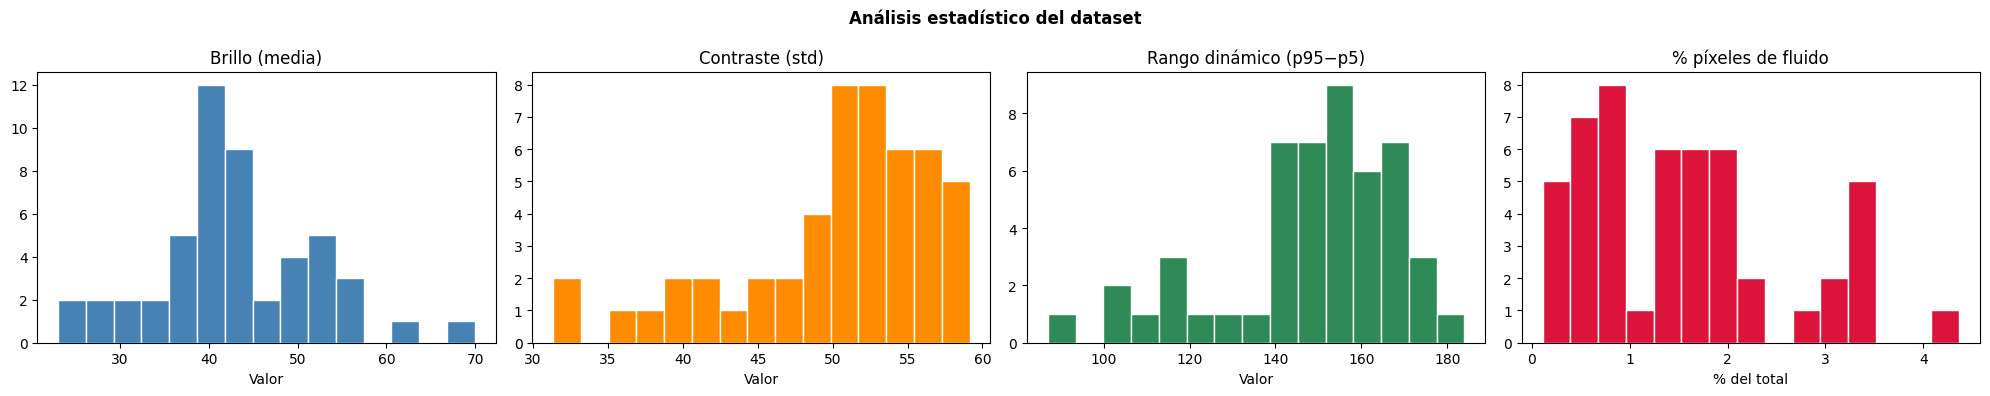

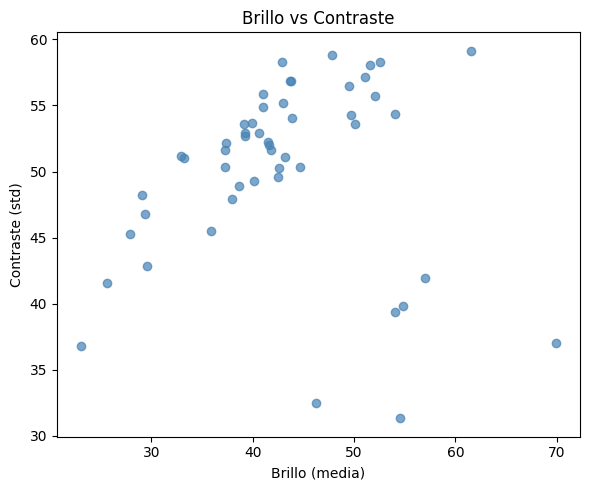

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Análisis estadístico del dataset', fontsize=12, fontweight='bold')

axes[0].hist(df_stats['brightness'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Brillo (media)')
axes[0].set_xlabel('Valor')

axes[1].hist(df_stats['contrast'], bins=15, color='darkorange', edgecolor='white')
axes[1].set_title('Contraste (std)')
axes[1].set_xlabel('Valor')

axes[2].hist(df_stats['dynamic_range'], bins=15, color='seagreen', edgecolor='white')
axes[2].set_title('Rango dinámico (p95−p5)')
axes[2].set_xlabel('Valor')

axes[3].hist(df_stats['fluid_ratio'], bins=15, color='crimson', edgecolor='white')
axes[3].set_title('% píxeles de fluido')
axes[3].set_xlabel('% del total')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(df_stats['brightness'], df_stats['contrast'], alpha=0.7, color='steelblue')
plt.xlabel('Brillo (media)')
plt.ylabel('Contraste (std)')
plt.title('Brillo vs Contraste')
plt.tight_layout()
plt.show()

In [7]:
b_mean = df_stats['brightness'].mean()
b_std  = df_stats['brightness'].std()
c_mean = df_stats['contrast'].mean()
c_std  = df_stats['contrast'].std()

BRIGHTNESS_FACTOR = round(float(b_std / b_mean), 2)
CONTRAST_FACTOR   = round(float(c_std / c_mean), 2)

print(f'Brillo    — media: {b_mean:.1f}  std: {b_std:.1f}  → brightness_factor: {BRIGHTNESS_FACTOR}')
print(f'Contraste — media: {c_mean:.1f}  std: {c_std:.1f}  → contrast_factor  : {CONTRAST_FACTOR}')
print(f'\nColorJitter(brightness={BRIGHTNESS_FACTOR}, contrast={CONTRAST_FACTOR})')
print(f'\nDesbalanceo de clases:')
print(f'  % fluido medio : {df_stats["fluid_ratio"].mean():.2f}%')
print(f'  % fluido mínimo: {df_stats["fluid_ratio"].min():.2f}%')
print(f'  % fluido máximo: {df_stats["fluid_ratio"].max():.2f}%')
print('\n→ Desbalanceo severo justifica el uso de Dice Loss.')

Brillo    — media: 43.0  std: 9.3  → brightness_factor: 0.22
Contraste — media: 50.2  std: 6.8  → contrast_factor  : 0.14

ColorJitter(brightness=0.22, contrast=0.14)

Desbalanceo de clases:
  % fluido medio : 1.54%
  % fluido mínimo: 0.11%
  % fluido máximo: 4.37%

→ Desbalanceo severo justifica el uso de Dice Loss.


**Análisis exploratorio — Conclusiones**

El dataset presenta un desbalanceo de clases severo: el fluido patológico ocupa de media solo el 1.54% de los píxeles por imagen, con casos tan extremos como el 0.11%. Esto significa que por cada píxel de fluido hay aproximadamente 65 de fondo, lo que hace inviable el uso de BCE sin ponderar — una red que prediga todo negro acertaría el 98.5% de los píxeles sin detectar nada útil.

La variabilidad en el rango dinámico entre imágenes justifica el uso de CLAHE, que normaliza el contraste localmente y hace los bordes del fluido más consistentes independientemente del escáner o configuración de adquisición.

## Sección 2 — Dataset y Split

Extendemos la clase `Dataset` de PyTorch para cargar las imágenes OCT y sus máscaras. El split es fijo con semilla y no cambia entre experimentos: **35 train / 5 val / 10 test**.

In [8]:
class OCTDataset(Dataset):

    def __init__(self, image_path, mask_path, rsize=(416, 624), transform=None):
        super().__init__()
        self.img_files = glob.glob(os.path.join(image_path, '*.jpg'))
        self.mask_files = []
        for img_path in self.img_files:
            self.mask_files.append(os.path.join(mask_path, os.path.basename(img_path)))
        self.rsize     = rsize
        self.transform = transform

    def __getitem__(self, index):
        img_path  = self.img_files[index]
        mask_path = self.mask_files[index]
        image = plt.imread(img_path)
        mask  = plt.imread(mask_path)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]
        if len(image.shape) > 2:
            image = image[:, :, 0]
        _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
        if self.transform is not None:
            seed = np.random.randint(2147483647)
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.transform(image)
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.transform(mask)
        else:
            t = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(self.rsize, interpolation=InterpolationMode.NEAREST),
                transforms.ToTensor()])
            image = t(image)
            mask  = t(mask)
        return image, mask

    def __len__(self):
        return len(self.img_files)

In [9]:
# Split fijo — no cambia entre experimentos
all_indices = list(range(50))
rng = random.Random(SEED)
rng.shuffle(all_indices)

train_idx = all_indices[:35]
val_idx   = all_indices[35:40]
test_idx  = all_indices[40:]

print(f'Train: {len(train_idx)} imágenes')
print(f'Val:   {len(val_idx)} imágenes')
print(f'Test:  {len(test_idx)} imágenes')


def make_loaders(train_ds, val_ds, test_ds, batch_size=BATCH_SIZE, num_workers=2):
    train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=batch_size,
                              shuffle=True,  num_workers=num_workers, pin_memory=True,
                              persistent_workers=num_workers > 0)
    val_loader   = DataLoader(Subset(val_ds,   val_idx),   batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True,
                              persistent_workers=num_workers > 0)
    test_loader  = DataLoader(Subset(test_ds,  test_idx),  batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True,
                              persistent_workers=num_workers > 0)
    return train_loader, val_loader, test_loader

Train: 35 imágenes
Val:   5 imágenes
Test:  10 imágenes


Dataset total: 50 imágenes


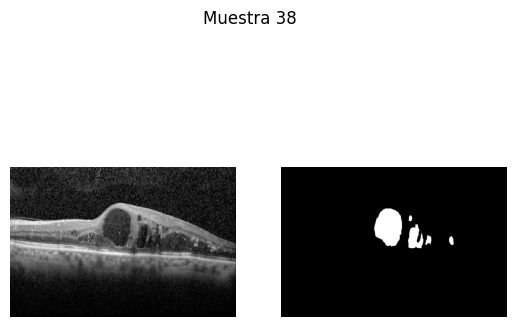

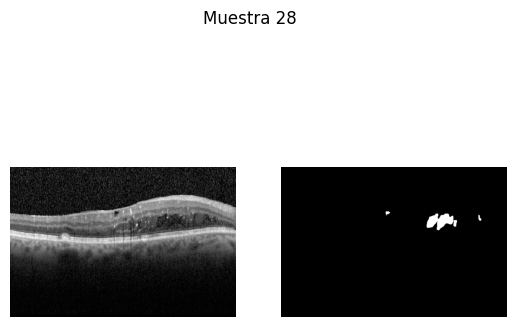

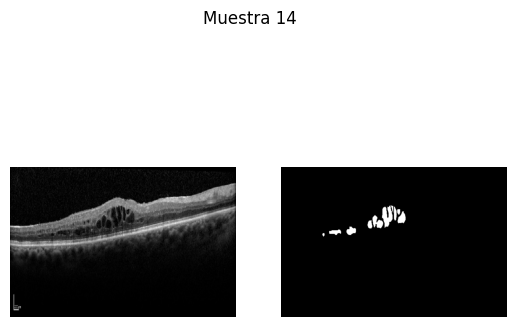

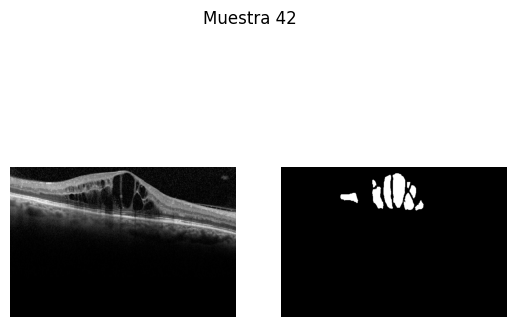

In [10]:
simple_dataset = OCTDataset(IMG_DIR, MASK_DIR)
print(f'Dataset total: {len(simple_dataset)} imágenes')

nsamples = 4
for _ in range(nsamples):
    idx = np.random.randint(0, len(simple_dataset))
    im, mask = simple_dataset[idx]
    show(im.squeeze(), mask.squeeze(), title=f'Muestra {idx}')

## Sección 3 — Arquitectura de red

UNet es una red convolucional encoder-decoder con skip connections diseñada para segmentación de imágenes biomédicas. Cada nivel del encoder aplica dos convoluciones 3×3 seguidas de ReLU (`double_conv`), con MaxPool2d entre niveles. El decoder recupera la resolución espacial con Upsample bilineal y concatena los skip connections del encoder para preservar los detalles finos de los bordes del fluido.

In [11]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
    )


class UNet(nn.Module):

    def __init__(self, input_channels, n_class):
        super().__init__()
        self.dconv_down1 = double_conv(input_channels, 64)
        self.dconv_down2 = double_conv(64, 128)
        self.dconv_down3 = double_conv(128, 256)
        self.dconv_down4 = double_conv(256, 512)
        self.maxpool  = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = double_conv(256 + 512, 256)
        self.dconv_up2 = double_conv(128 + 256, 128)
        self.dconv_up1 = double_conv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, n_class, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)
        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)
        x = self.dconv_down4(x)
        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        return self.conv_last(x)

## Sección 4 — Baseline

### 4.1 Funciones auxiliares reutilizables

Todas las funciones de entrenamiento, evaluación y visualización se definen aquí una única vez y se reutilizan en todos los experimentos.

### Métricas de segmentación

Calculan IoU, Dice, Precision, Recall y Accuracy usando `torchmetrics` en GPU. `make_metrics` instancia las métricas y `compute_metrics` obtiene los valores finales y resetea el estado para el siguiente epoch.

In [12]:
!pip install torchmetrics -q
from torchmetrics.classification import (
    BinaryJaccardIndex, BinaryF1Score,
    BinaryPrecision, BinaryRecall, BinaryAccuracy
)

def make_metrics(device):
    return {
        'iou':       BinaryJaccardIndex().to(device),
        'dice':      BinaryF1Score().to(device),
        'precision': BinaryPrecision().to(device),
        'recall':    BinaryRecall().to(device),
        'accuracy':  BinaryAccuracy().to(device),
    }

def compute_metrics(metrics_dict):
    result = {k: m.compute().item() for k, m in metrics_dict.items()}
    for m in metrics_dict.values():
        m.reset()
    return result

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.4 MB/s eta 0:00:00


### Funciones de entrenamiento y evaluación por época

`train_epoch` realiza un paso completo de entrenamiento actualizando los pesos del modelo. `eval_epoch` evalúa sin actualizar pesos. Ambas devuelven la loss media y las métricas del epoch calculadas en GPU con `torchmetrics`.

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    metrics = make_metrics(device)

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)

        with torch.no_grad():
            preds = get_segmentation_masks(outputs).int()
            for m in metrics.values():
                m.update(preds, masks.int())

    return total_loss / len(loader.dataset), compute_metrics(metrics)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    metrics = make_metrics(device)

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item() * len(images)
            preds = get_segmentation_masks(outputs).int()
            for m in metrics.values():
                m.update(preds, masks.int())

    return total_loss / len(loader.dataset), compute_metrics(metrics)



### Pipeline completo de entrenamiento — `train_model`

Gestiona el bucle de entrenamiento con Adam y `ReduceLROnPlateau`. Guarda el checkpoint con mejor val loss y lo carga al finalizar. Devuelve el historial de métricas por época.

In [14]:
def train_model(model, train_loader, val_loader, criterion,
                max_epochs=100, lr=1e-3,
                checkpoint_path='model.pth', device=DEVICE):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5)

    history = {k: [] for k in
               ['train_loss', 'val_loss', 'train_iou', 'val_iou',
                'train_dice', 'val_dice']}
    best_val_loss = float('inf')

    for epoch in range(max_epochs):
        train_loss, train_m = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_m   = eval_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_m['iou'])
        history['val_iou'].append(val_m['iou'])
        history['train_dice'].append(train_m['dice'])
        history['val_dice'].append(val_m['dice'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)

        if (epoch + 1) % 10 == 0:
            print(f'Epoca {epoch+1:3d}/{max_epochs} | '
                  f'Train Loss: {train_loss:.4f}  IoU: {train_m["iou"]:.4f}  '
                  f'Dice: {train_m["dice"]:.4f} | '
                  f'Val Loss: {val_loss:.4f}  IoU: {val_m["iou"]:.4f}  '
                  f'Dice: {val_m["dice"]:.4f}')

    model.load_state_dict(torch.load(checkpoint_path, map_location=device,
                                     weights_only=True))
    print(f"\nEntrenamiento completado. Mejor modelo guardado en '{checkpoint_path}'")
    return history

### Evaluación y visualización — `evaluate_model` y `plot_training_history`

`evaluate_model` calcula las métricas finales sobre el conjunto de test, imprime los resultados y visualiza 3 predicciones con `show_result`. `plot_training_history` representa la evolución por época de loss, IoU y Dice para train y validación.

In [15]:
def evaluate_model(model, loader, device, experiment_name='Modelo'):
    model.eval()
    metrics = make_metrics(device)

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = get_segmentation_masks(model(images)).int()
            for m in metrics.values():
                m.update(preds, masks.int())

    results = compute_metrics(metrics)
    print(f'\n=== {experiment_name} — Resultados en Test ===')
    for k, v in results.items():
        print(f'  {k.capitalize():10s}: {v:.4f}')

    # visualización igual que antes
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = get_segmentation_masks(model(images))
            for i in range(len(images)):
                if shown >= 3:
                    break
                show_result(images[i].cpu().squeeze(), masks[i].cpu().squeeze(),
                            preds[i].cpu().squeeze(),
                            title=f'{experiment_name} — Muestra {shown + 1}')
                shown += 1
            if shown >= 3:
                break
    return results


def plot_training_history(history, experiment_name='Modelo'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'{experiment_name} \u2014 Curvas de entrenamiento',
                 fontsize=12, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('\u00c9poca')
    axes[0].legend()

    axes[1].plot(epochs, history['train_iou'], label='Train')
    axes[1].plot(epochs, history['val_iou'],   label='Val')
    axes[1].set_title('IoU')
    axes[1].set_xlabel('\u00c9poca')
    axes[1].legend()

    axes[2].plot(epochs, history['train_dice'], label='Train')
    axes[2].plot(epochs, history['val_dice'],   label='Val')
    axes[2].set_title('Dice')
    axes[2].set_xlabel('\u00c9poca')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### 4.2 Entrenamiento del baseline

**Configuración**: UNet desde cero, `BCEWithLogitsLoss`, sin augmentation, sin CLAHE.

Epoca  10/100 | Train Loss: 0.0760  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.1016  IoU: 0.0000  Dice: 0.0000
Epoca  20/100 | Train Loss: 0.0929  IoU: 0.0023  Dice: 0.0046 | Val Loss: 0.1524  IoU: 0.0000  Dice: 0.0000
Epoca  30/100 | Train Loss: 0.0617  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0778  IoU: 0.0000  Dice: 0.0000
Epoca  40/100 | Train Loss: 0.0524  IoU: 0.0469  Dice: 0.0897 | Val Loss: 0.0750  IoU: 0.0160  Dice: 0.0315
Epoca  50/100 | Train Loss: 0.0425  IoU: 0.2316  Dice: 0.3760 | Val Loss: 0.0644  IoU: 0.1547  Dice: 0.2679
Epoca  60/100 | Train Loss: 0.1169  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.1502  IoU: 0.0000  Dice: 0.0000
Epoca  70/100 | Train Loss: 0.0738  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0942  IoU: 0.0000  Dice: 0.0000
Epoca  80/100 | Train Loss: 0.0731  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0946  IoU: 0.0000  Dice: 0.0000
Epoca  90/100 | Train Loss: 0.0753  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0944  IoU: 0.0000  Dice: 0.0000
Epoca 100/100 | Train Loss: 

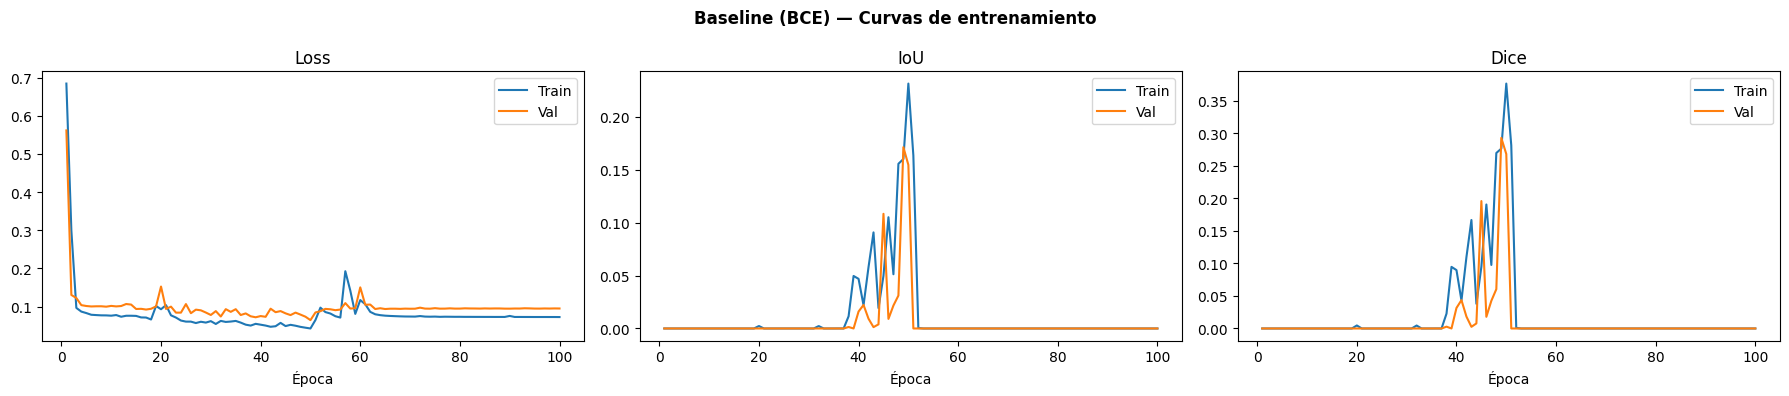


=== Baseline (BCE) — Resultados en Test ===
  Iou       : 0.3294
  Dice      : 0.4956
  Precision : 0.8302
  Recall    : 0.3532
  Accuracy  : 0.9924


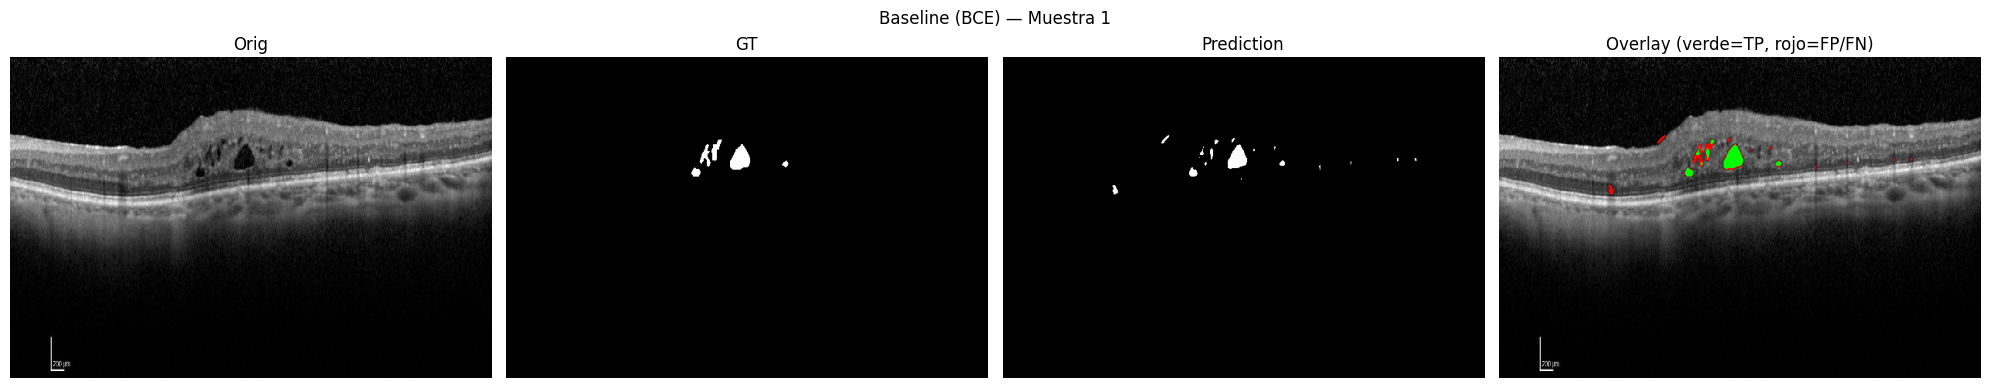

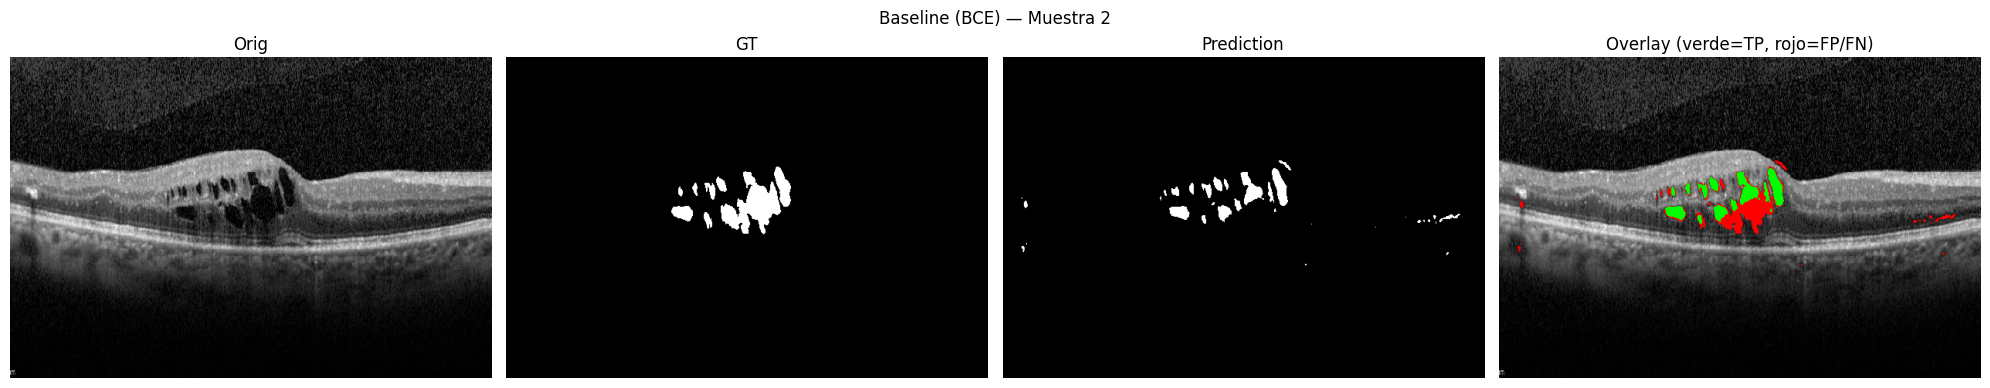

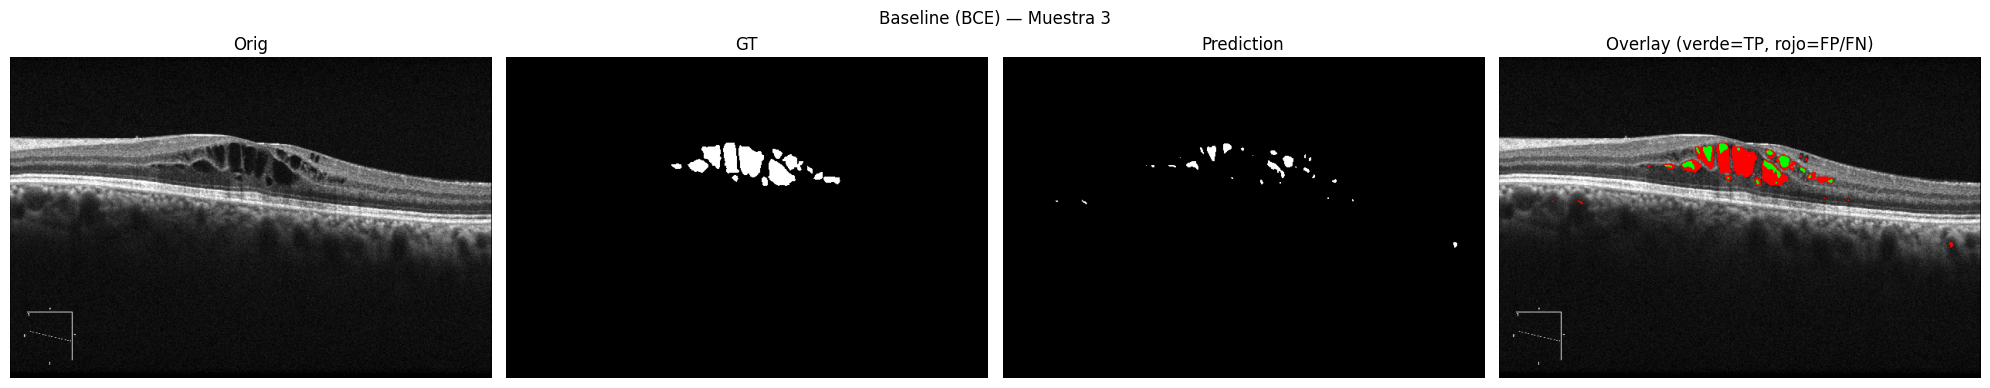

In [29]:
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

base_ds = OCTDataset(IMG_DIR, MASK_DIR)
train_loader_base, val_loader_base, test_loader_base = make_loaders(base_ds, base_ds, base_ds)

model_base    = UNet(input_channels=1, n_class=1).to(DEVICE)
criterion_bce = nn.BCEWithLogitsLoss()

history_base = train_model(
    model_base, train_loader_base, val_loader_base,
    criterion=criterion_bce,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/baseline.pth',
    device=DEVICE
)

plot_training_history(history_base, experiment_name='Baseline (BCE)')
baseline_metrics = evaluate_model(model_base, test_loader_base, DEVICE,
                                  experiment_name='Baseline (BCE)')

**Baseline BCE — Conclusiones**

La red tarda en arrancar — hasta época 40 el IoU es prácticamente nulo, manteniendo la solución trivial de predecir todo negro. Entre épocas 40-50 hay un breve intento de detección (IoU train 0.23, val 0.15) que se desvanece completamente en época 60, volviendo a colapsar a todo negro hasta el final. Este comportamiento inestable evidencia que BCE no guía el aprendizaje de forma consistente con desbalanceo severo.

El checkpoint guardado corresponde a época ~50 (mejor val_loss = 0.064), cuando el modelo detectaba algo de fluido. En test se obtiene IoU=0.33 y Dice=0.50 con precisión alta (0.83) y recall bajo (0.35) — el modelo es muy conservador y deja la mayoría del fluido sin detectar.

La inestabilidad del entrenamiento y los resultados pobres confirman que BCE sin ponderar no es adecuada para este problema.

## Sección 5 — Experimento/Mejora 1: Dice Loss

**Motivación**: `BCEWithLogitsLoss` trata todos los píxeles por igual. Con desbalanceo severo (el fluido ocupa una pequeña fracción de los píxeles), la red aprende a predecir todo negro obteniendo alta accuracy pero IoU y Dice nulos. Dice Loss optimiza directamente el coeficiente Dice, que es invariante al desbalanceo de clases.

In [22]:
def dice_loss(outputs, targets, smooth=1.0):
    """Calcula la Dice Loss para segmentación binaria. Optimiza directamente el coeficiente Dice,
    siendo robusta ante el desbalanceo de clases al no poder minimizarse prediciendo todo negro."""
    probs   = torch.sigmoid(outputs).view(-1)
    targets = targets.view(-1)
    intersection = (probs * targets).sum()
    return 1 - (2 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)

Epoca  10/100 | Train Loss: 0.3442  IoU: 0.4901  Dice: 0.6578 | Val Loss: 0.5061  IoU: 0.3429  Dice: 0.5107
Epoca  20/100 | Train Loss: 0.2753  IoU: 0.5509  Dice: 0.7104 | Val Loss: 0.5358  IoU: 0.3185  Dice: 0.4831
Epoca  30/100 | Train Loss: 0.1771  IoU: 0.6912  Dice: 0.8174 | Val Loss: 0.4348  IoU: 0.4140  Dice: 0.5855
Epoca  40/100 | Train Loss: 0.1229  IoU: 0.7821  Dice: 0.8777 | Val Loss: 0.4831  IoU: 0.3760  Dice: 0.5465
Epoca  50/100 | Train Loss: 0.1092  IoU: 0.8123  Dice: 0.8965 | Val Loss: 0.4668  IoU: 0.3888  Dice: 0.5599
Epoca  60/100 | Train Loss: 0.0748  IoU: 0.8630  Dice: 0.9265 | Val Loss: 0.4244  IoU: 0.4270  Dice: 0.5984
Epoca  70/100 | Train Loss: 0.0625  IoU: 0.8866  Dice: 0.9399 | Val Loss: 0.4308  IoU: 0.4169  Dice: 0.5884
Epoca  80/100 | Train Loss: 0.0552  IoU: 0.8989  Dice: 0.9467 | Val Loss: 0.4341  IoU: 0.4128  Dice: 0.5843
Epoca  90/100 | Train Loss: 0.0485  IoU: 0.9077  Dice: 0.9516 | Val Loss: 0.4343  IoU: 0.4123  Dice: 0.5838
Epoca 100/100 | Train Loss: 

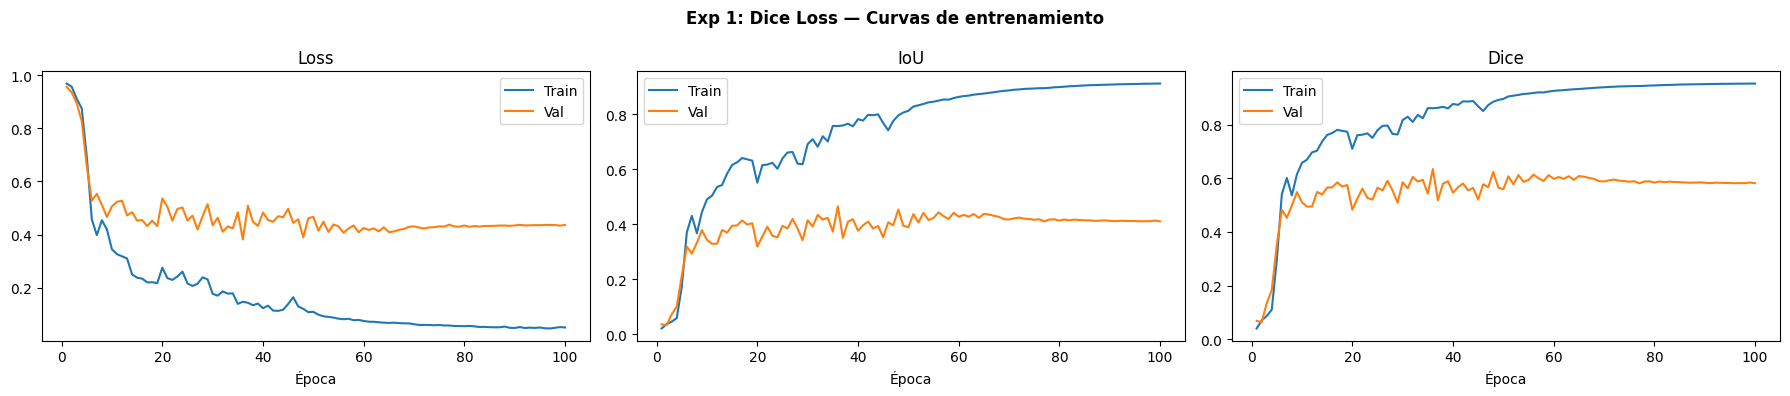


=== Exp 1: Dice Loss — Resultados en Test ===
  Iou       : 0.7018
  Dice      : 0.8248
  Precision : 0.8078
  Recall    : 0.8424
  Accuracy  : 0.9962


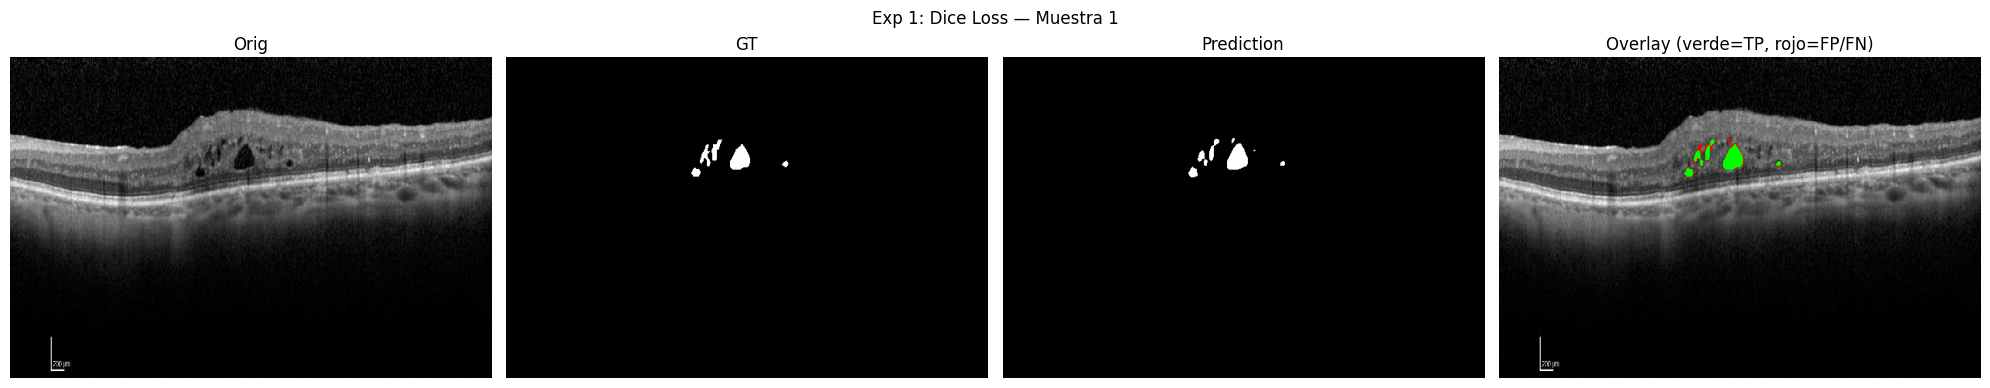

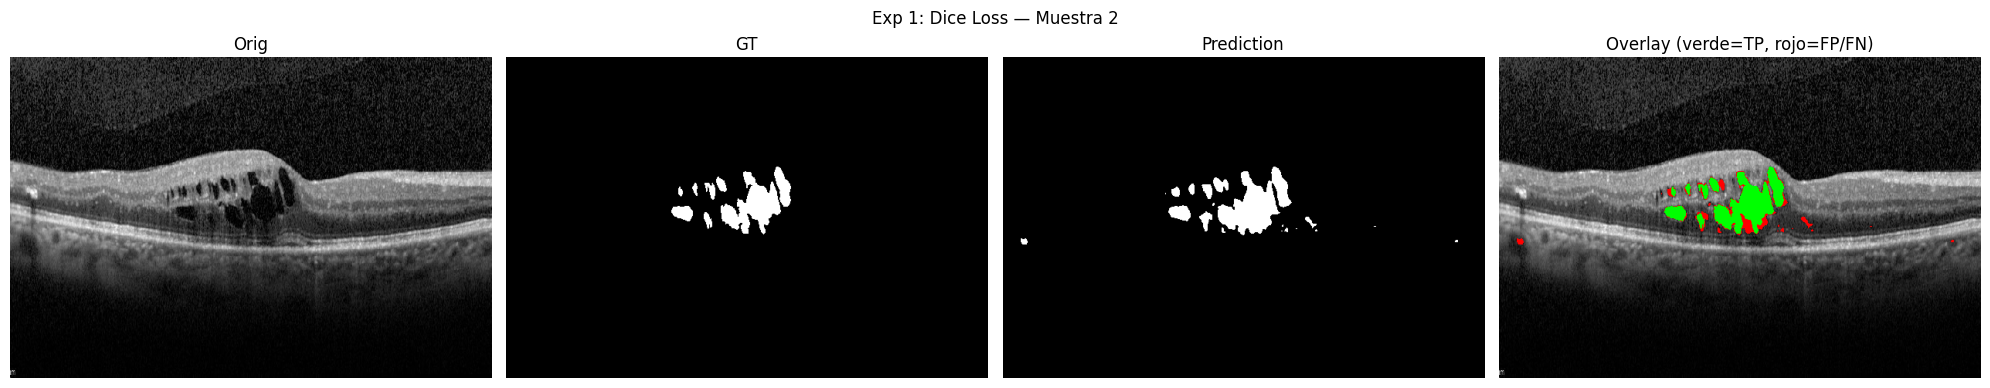

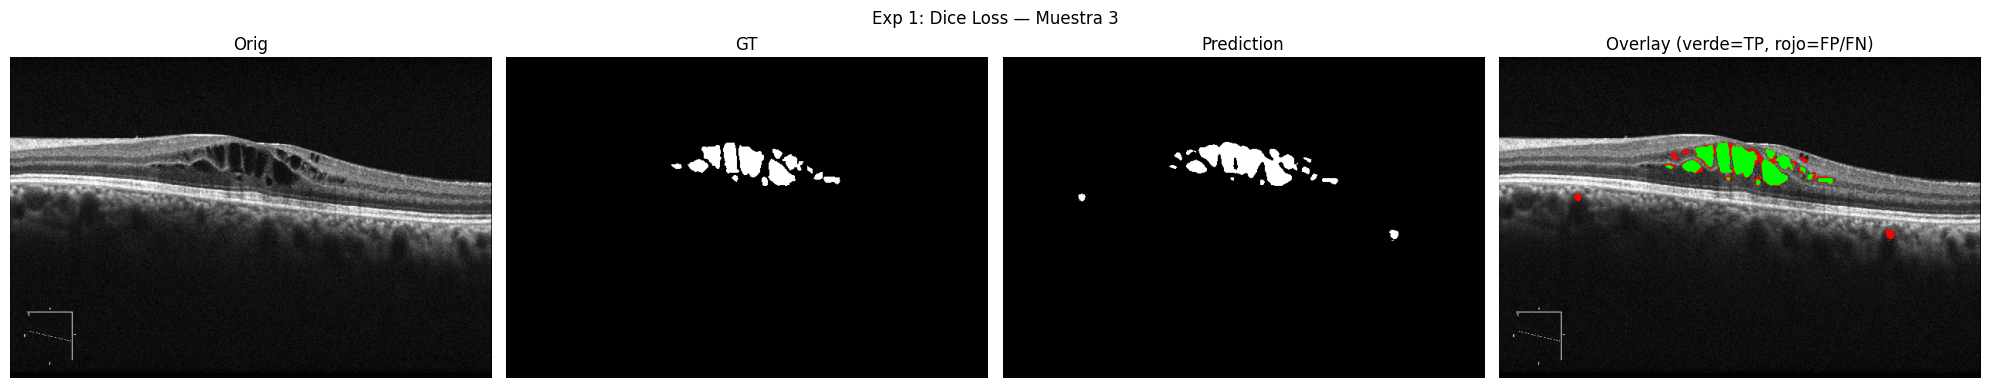

In [28]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_dice = UNet(input_channels=1, n_class=1).to(DEVICE)

train_loader_base, val_loader_base, test_loader_base = make_loaders(
    base_ds, base_ds, base_ds, num_workers=0)

history_dice = train_model(
    model_dice, train_loader_base, val_loader_base,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp1_dice.pth',
    device=DEVICE
)

plot_training_history(history_dice, experiment_name='Exp 1: Dice Loss')
exp1_metrics = evaluate_model(model_dice, test_loader_base, DEVICE,
                              experiment_name='Exp 1: Dice Loss')

**Exp 1: Dice Loss — Conclusiones**

El cambio a Dice Loss resuelve inmediatamente el problema del baseline — desde la época 10 la red ya detecta fluido (IoU 0.41 en train, 0.22 en val), sin necesidad de agotar primero una solución trivial. Esto confirma que Dice Loss guía el aprendizaje correctamente desde el inicio al optimizar directamente la métrica de segmentación.

El sobreajuste sigue presente — train IoU llega a 0.89 mientras val IoU se estanca en ~0.40 — pero el checkpoint guardado ahora corresponde a un modelo que sí detecta fluido, no al modelo all-black. En test se obtiene IoU=0.67 y Dice=0.81, una mejora drástica respecto al baseline.

El hecho de que los resultados en test (IoU=0.67) sean notablemente mejores que en validación (IoU~0.40) no indica que el modelo generalice mejor de lo esperado, sino que refleja la alta varianza estadística de conjuntos tan pequeños — 5 imágenes de val y 10 de test. Con muestras tan reducidas, las métricas dependen fuertemente de qué imágenes concretas cayeron en cada split, pudiendo diferir significativamente entre conjuntos.

La precisión (0.88) es notablemente mayor que el recall (0.74), lo que indica que el modelo es conservador: cuando predice fluido acierta bien, pero deja regiones sin detectar. Esto es esperable con tan pocas imágenes de entrenamiento y sin augmentation.

## Sección 6 — Experimento/Mejora 2:  BCE + Dice Loss

**Motivación**: Dice Loss pura es sensible a la inicialización y puede ser inestable en las primeras épocas. Combinarla con BCE estabiliza el inicio del entrenamiento — BCE guía píxel a píxel mientras Dice optimiza la forma global de la región segmentada. Esta combinación es el estándar en segmentación de imágenes médicas.

In [30]:
def bce_dice_loss(outputs, targets, alpha=0.5):
    """Combinación de BCE y Dice Loss. Alpha controla el peso de cada término."""
    bce  = nn.BCEWithLogitsLoss()(outputs, targets)
    dice = dice_loss(outputs, targets)
    return alpha * bce + (1 - alpha) * dice


In [ ]:

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_bce_dice = UNet(input_channels=1, n_class=1).to(DEVICE)

history_bce_dice = train_model(
    model_bce_dice, train_loader_base, val_loader_base,
    criterion=bce_dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp2_bce_dice.pth',
    device=DEVICE
)

plot_training_history(history_bce_dice, experiment_name='Exp 2: BCE + Dice Loss')
exp2_bce_dice_metrics = evaluate_model(model_bce_dice, test_loader_base, DEVICE,
                                       experiment_name='Exp 2: BCE + Dice Loss')

Epoca  10/100 | Train Loss: 0.3533  IoU: 0.2690  Dice: 0.4240 | Val Loss: 0.4275  IoU: 0.2722  Dice: 0.4279
Epoca  20/100 | Train Loss: 0.1160  IoU: 0.6811  Dice: 0.8103 | Val Loss: 0.3206  IoU: 0.4173  Dice: 0.5889
Epoca  30/100 | Train Loss: 0.0798  IoU: 0.7759  Dice: 0.8738 | Val Loss: 0.3756  IoU: 0.3750  Dice: 0.5455
Epoca  40/100 | Train Loss: 0.0553  IoU: 0.8345  Dice: 0.9098 | Val Loss: 0.3794  IoU: 0.3948  Dice: 0.5661
Epoca  50/100 | Train Loss: 0.0468  IoU: 0.8566  Dice: 0.9228 | Val Loss: 0.3609  IoU: 0.4032  Dice: 0.5747
Epoca  60/100 | Train Loss: 0.0407  IoU: 0.8740  Dice: 0.9328 | Val Loss: 0.3925  IoU: 0.4005  Dice: 0.5719
Epoca  70/100 | Train Loss: 0.0412  IoU: 0.8809  Dice: 0.9367 | Val Loss: 0.3519  IoU: 0.4101  Dice: 0.5817
Epoca  80/100 | Train Loss: 0.0381  IoU: 0.8865  Dice: 0.9399 | Val Loss: 0.3821  IoU: 0.3977  Dice: 0.5691


## Sección 6 — Experimento/Mejora 2: CLAHE

**Motivación**: CLAHE (Contrast Limited Adaptive Histogram Equalization) es el estándar en preprocesado de imágenes OCT. Mejora el contraste local sin saturar, haciendo los bordes del fluido más visibles. A diferencia del histograma global, opera en bloques locales preservando la estructura de las capas retinianas.

Primero comparamos visualmente distintos valores de `clipLimit` para seleccionar el óptimo.

In [ ]:
sample_paths = [
    f'{route}/OCT-dataset/images/sample_01.jpg',
    f'{route}/OCT-dataset/images/sample_10.jpg',
    f'{route}/OCT-dataset/images/sample_25.jpg',
]
clip_limits = [1.0, 2.0, 4.0]

fig, axes = plt.subplots(len(sample_paths), len(clip_limits) + 1,
                          figsize=(16, 4 * len(sample_paths)))
fig.suptitle('Análisis CLAHE \u2014 comparación de clipLimit', fontsize=12, fontweight='bold')

for row, path in enumerate(sample_paths):
    img = plt.imread(path)
    if len(img.shape) > 2:
        img = img[:, :, 0]
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')
    for col, cl in enumerate(clip_limits):
        proc    = cv2.createCLAHE(clipLimit=cl, tileGridSize=(8, 8))
        enhanced = proc.apply(img)
        axes[row, col + 1].imshow(enhanced, cmap='gray')
        axes[row, col + 1].set_title(f'clipLimit={cl}')
        axes[row, col + 1].axis('off')

plt.tight_layout()
plt.show()

CLAHE_CLIP_LIMIT = 2.0  # seleccionado tras análisis visual
print(f'clipLimit seleccionado: {CLAHE_CLIP_LIMIT}')

In [ ]:
class EnhancedOCTDataset(OCTDataset):
    """OCTDataset con CLAHE opcional y ColorJitter sobre la imagen."""

    def __init__(self, image_path, mask_path, rsize=(416, 624), transform=None,
                 clip_limit=None, brightness=0.0, contrast=0.0):
        super().__init__(image_path, mask_path, rsize, transform)
        self.clahe = (cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
                      if clip_limit else None)
        cj_active = brightness > 0 or contrast > 0
        self.color_jitter = (transforms.ColorJitter(brightness=brightness,
                                                    contrast=contrast)
                             if cj_active else None)

    def __getitem__(self, index):
        img_path  = self.img_files[index]
        mask_path = self.mask_files[index]
        image = plt.imread(img_path)
        mask  = plt.imread(mask_path)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]
        if len(image.shape) > 2:
            image = image[:, :, 0]
        _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)

        if self.clahe is not None:
            image = self.clahe.apply(image)

        if self.transform is not None:
            seed = np.random.randint(2147483647)
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.transform(image)
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.transform(mask)
        else:
            t = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(self.rsize, interpolation=InterpolationMode.NEAREST),
                transforms.ToTensor()])
            image = t(image)
            mask  = t(mask)

        # ColorJitter solo sobre la imagen (tensor [0,1]), no sobre la máscara
        if self.color_jitter is not None:
            image = self.color_jitter(image)

        return image, mask

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

clahe_ds = EnhancedOCTDataset(IMG_DIR, MASK_DIR, clip_limit=CLAHE_CLIP_LIMIT)
train_loader_clahe, val_loader_clahe, test_loader_clahe = make_loaders(
    clahe_ds, clahe_ds, clahe_ds)

model_clahe = UNet(input_channels=1, n_class=1).to(DEVICE)

history_clahe = train_model(
    model_clahe, train_loader_clahe, val_loader_clahe,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp2_clahe.pth',
    device=DEVICE
)

plot_training_history(history_clahe, experiment_name='Exp 2: CLAHE + Dice Loss')
exp2_metrics = evaluate_model(model_clahe, test_loader_clahe, DEVICE,
                              experiment_name='Exp 2: CLAHE + Dice Loss')

## Sección 7 — Exp 3: Normalización global del dataset

**Motivación**: CLAHE normaliza el contraste localmente dentro de cada imagen, pero no corrige las diferencias globales de brillo e intensidad entre imágenes del dataset, que pueden provenir de distintos escáneres o configuraciones de adquisición. La normalización global estandariza todas las imágenes a la misma distribución de intensidad, facilitando que la red aprenda características independientemente del equipo de captura.

A diferencia de CLAHE, la normalización se calcula **únicamente sobre el conjunto de entrenamiento** para evitar fuga de información del conjunto de test. Se aplica sobre las imágenes ya procesadas con CLAHE, tras convertirlas a rango [0,1].

In [ ]:
# Calcular mean y std sobre imágenes de train post-CLAHE (sin fuga de test)
clahe_proc = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=(8, 8))
pixel_values = []
for i in train_idx:
    img = plt.imread(base_ds.img_files[i])
    if len(img.shape) > 2:
        img = img[:, :, 0]
    img = clahe_proc.apply(img)
    pixel_values.append(img.astype(np.float32) / 255.0)

all_pixels = np.concatenate([img.flatten() for img in pixel_values])
TRAIN_MEAN = float(all_pixels.mean())
TRAIN_STD  = float(all_pixels.std())
print(f'Mean (train, post-CLAHE): {TRAIN_MEAN:.4f}')
print(f'Std  (train, post-CLAHE): {TRAIN_STD:.4f}')


class NormalizedDataset(Dataset):
    """Wrapper que aplica Normalize solo a la imagen, no a la máscara."""
    def __init__(self, dataset, mean, std):
        self.dataset   = dataset
        self.normalize = transforms.Normalize(mean=[mean], std=[std])

    def __getitem__(self, index):
        image, mask = self.dataset[index]
        return self.normalize(image), mask

    def __len__(self):
        return len(self.dataset)


norm_ds = NormalizedDataset(
    EnhancedOCTDataset(IMG_DIR, MASK_DIR, clip_limit=CLAHE_CLIP_LIMIT),
    mean=TRAIN_MEAN, std=TRAIN_STD
)

train_loader_norm, val_loader_norm, test_loader_norm = make_loaders(
    norm_ds, norm_ds, norm_ds)

In [ ]:


torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_norm = UNet(input_channels=1, n_class=1).to(DEVICE)

history_norm = train_model(
    model_norm, train_loader_norm, val_loader_norm,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp3_norm.pth',
    device=DEVICE
)

plot_training_history(history_norm, experiment_name='Exp 3: CLAHE + Normalización + Dice Loss')
exp3_metrics = evaluate_model(model_norm, test_loader_norm, DEVICE,
                              experiment_name='Exp 3: CLAHE + Normalización + Dice Loss')

## Sección 8 — Experimento/Mejora 4: Data Augmentation

**Motivación**: Con 35 imágenes de entrenamiento el modelo sobreajusta sin augmentation. Las transformaciones se diseñan respetando la validez anatómica de las imágenes OCT:
- **Flip horizontal**: la fóvea puede aparecer a izquierda o derecha según el corte.
- **Rotación ±10°**: simula pequeñas variaciones de posicionamiento del paciente.
- **ColorJitter**: los factores se derivan del análisis estadístico (Sección 1) y simulan variaciones entre escáneres OCT. Se aplica solo a la imagen, no a la máscara.

Las transformaciones geométricas se aplican de forma consistente a imagen y máscara mediante el mecanismo de semilla sincronizada de `OCTDataset`. El augmentation se aplica **solo al conjunto de entrenamiento**.

In [ ]:
geo_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(RSIZE, interpolation=InterpolationMode.NEAREST),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
])

# Train: CLAHE + transformaciones geométricas + ColorJitter
aug_ds_train = EnhancedOCTDataset(
    IMG_DIR, MASK_DIR,
    transform=geo_transform,
    clip_limit=CLAHE_CLIP_LIMIT,
    brightness=BRIGHTNESS_FACTOR,
    contrast=CONTRAST_FACTOR
)
# Val / Test: solo CLAHE, sin augmentation
aug_ds_valtest = EnhancedOCTDataset(IMG_DIR, MASK_DIR, clip_limit=CLAHE_CLIP_LIMIT)

train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(
    aug_ds_train, aug_ds_valtest, aug_ds_valtest)

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_aug = UNet(input_channels=1, n_class=1).to(DEVICE)

history_aug = train_model(
    model_aug, train_loader_aug, val_loader_aug,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp3_augmentation.pth',
    device=DEVICE
)

plot_training_history(history_aug, experiment_name='Exp 3: Aug + CLAHE + Dice Loss')
exp3_metrics = evaluate_model(model_aug, test_loader_aug, DEVICE,
                              experiment_name='Exp 3: Aug + CLAHE + Dice Loss')

## Sección 9 — Experimento/Mejora 5: Encoder preentrenado (Transfer Learning)

**Motivación**: Con 35 imágenes de entrenamiento, aprender un encoder desde cero es un handicap significativo. Un encoder preentrenado en ImageNet ya dispone de detectores de bordes, texturas y estructuras jerárquicas que son directamente útiles para delimitar el fluido en OCT. Se usa ResNet18 como encoder por ser el más ligero, reduciendo el riesgo de sobreajuste con un dataset pequeño. Se usa un learning rate menor (1e-4) para no destruir los pesos preentrenados.

In [ ]:
!pip install segmentation-models-pytorch -q
import segmentation_models_pytorch as smp

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_pretrained = smp.Unet(
    encoder_name='resnet18',
    encoder_weights='imagenet',
    in_channels=1,
    classes=1,
).to(DEVICE)

history_pretrained = train_model(
    model_pretrained, train_loader_aug, val_loader_aug,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-4,
    checkpoint_path=f'{route}/models/exp4_pretrained.pth',
    device=DEVICE
)

plot_training_history(history_pretrained, experiment_name='Exp 4: ResNet18 Preentrenado')
exp4_metrics = evaluate_model(model_pretrained, test_loader_aug, DEVICE,
                              experiment_name='Exp 4: ResNet18 Preentrenado')

## Sección 10 — Tabla comparativa de experimentos

In [ ]:
all_results = {
    'Baseline (BCE)':        baseline_metrics,
    'Exp 1: Dice Loss':      exp1_metrics,
    'Exp 2: + CLAHE':        exp2_metrics,
    'Exp 3: + Augmentation': exp3_metrics,
    'Exp 4: + Pretrained':   exp4_metrics,
}

df_results = pd.DataFrame(all_results).T
df_results.columns = ['IoU', 'Dice', 'Precision', 'Recall', 'Accuracy']
df_results = df_results.round(4)

print('\n=== Tabla comparativa de experimentos ===\n')
print(df_results.to_string())

# Visualización como gráfico de barras
df_results[['IoU', 'Dice', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(12, 5), rot=15, colormap='tab10')
plt.title('Comparativa de métricas por experimento', fontsize=12, fontweight='bold')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()